In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
resume_df = pd.read_csv(
    r"D:\AI_ATS_Resume_Screening_System\resume\test\csv\clean_resume_data.csv"
)

resume_df.head()


,resume_name,resume_text,text_length,length_category,completeness_score,clean_text
0,Abiral_Pandey_Fullstack_Java.pdf,Name: Abiral Pandey\nEmail: abiral.pandey88@gm...,13972,Long,3,name abiral pandey email phone current locatio...
1,Anudeep N_Sr Java Developer.pdf,Anudeep\nSr Java Programmer\nanudeepreddynalla...,12049,Long,4,anudeep sr java programmer professional summar...
2,Ashwini J2EE Developer.pdf,Ashwini C\n©732-352-1613\nashwinicha8@gmail.co...,19615,Long,4,ashwini c © sr javajee developer summary aroun...
3,Bapuji Hadoop developer.pdf,Bapuji\nSr. Hadoop Developer\nPhone: +1(224)-7...,14384,Long,4,bapuji sr hadoop developer phone email profess...
4,CHETAN_Sr Java Developer.pdf,CHETAN BABU\nMobile: 405-896-0512\nEmail: boor...,13237,Long,3,chetan babu mobile email professional summary ...


In [3]:
skills = [

    "python",
    "sql",
    "excel",
    "power bi",
    "tableau",

    "machine learning",
    "deep learning",

    "statistics",
    "data analysis",

    "pandas",
    "numpy",

    "scikit learn",
    "tensorflow",
    "keras",

    "r",
    "sas",

    "data visualization",

    "mysql",
    "postgresql",

    "github",

    "spark",
    "hadoop"
]

In [4]:
def extract_skills(text):

    text = str(text).lower()

    found_skills = []

    for skill in skills:

        if skill in text:
            found_skills.append(skill)

    return found_skills

In [5]:
resume_df["skills_found"] = resume_df["clean_text"].apply(
    extract_skills
)

In [6]:
resume_df[
    [
        "resume_name",
        "skills_found"
    ]
].head()

,resume_name,skills_found
0,Abiral_Pandey_Fullstack_Java.pdf,"[sql, excel, r, sas, mysql, postgresql, github]"
1,Anudeep N_Sr Java Developer.pdf,"[sql, r, sas, mysql, github]"
2,Ashwini J2EE Developer.pdf,"[sql, excel, r, mysql, postgresql, github, spark]"
3,Bapuji Hadoop developer.pdf,"[python, sql, excel, tableau, r, mysql, github..."
4,CHETAN_Sr Java Developer.pdf,"[sql, excel, r, mysql]"


In [7]:
resume_df["skill_count"] = resume_df["skills_found"].apply(len)

resume_df[
    [
        "resume_name",
        "skill_count"
    ]
].head()

,resume_name,skill_count
0,Abiral_Pandey_Fullstack_Java.pdf,7
1,Anudeep N_Sr Java Developer.pdf,5
2,Ashwini J2EE Developer.pdf,7
3,Bapuji Hadoop developer.pdf,9
4,CHETAN_Sr Java Developer.pdf,4


In [8]:
top_candidates = resume_df.sort_values(
    by="skill_count",
    ascending=False
)

top_candidates[
    [
        "resume_name",
        "skill_count"
    ]
].head(10)

,resume_name,skill_count
3,Bapuji Hadoop developer.pdf,9
12,Mani_Hadoop.pdf,8
18,Sai Srinivas_Sr_Java_Developer.pdf,8
0,Abiral_Pandey_Fullstack_Java.pdf,7
2,Ashwini J2EE Developer.pdf,7
19,Sharath Java.pdf,7
26,vikas java.pdf,6
25,Venkata_SrPHP_Developer.pdf,6
24,Tarun_Developer.pdf,6
23,Sundar_Java_8 Years.pdf,6


In [9]:
all_skills = []

for skills_list in resume_df["skills_found"]:

    all_skills.extend(skills_list)

skill_frequency = Counter(all_skills)

skill_frequency

Counter({'sql': 28,
         'r': 28,
         'mysql': 25,
         'excel': 21,
         'github': 12,
         'sas': 11,
         'spark': 9,
         'python': 7,
         'hadoop': 6,
         'postgresql': 5,
         'tableau': 2})

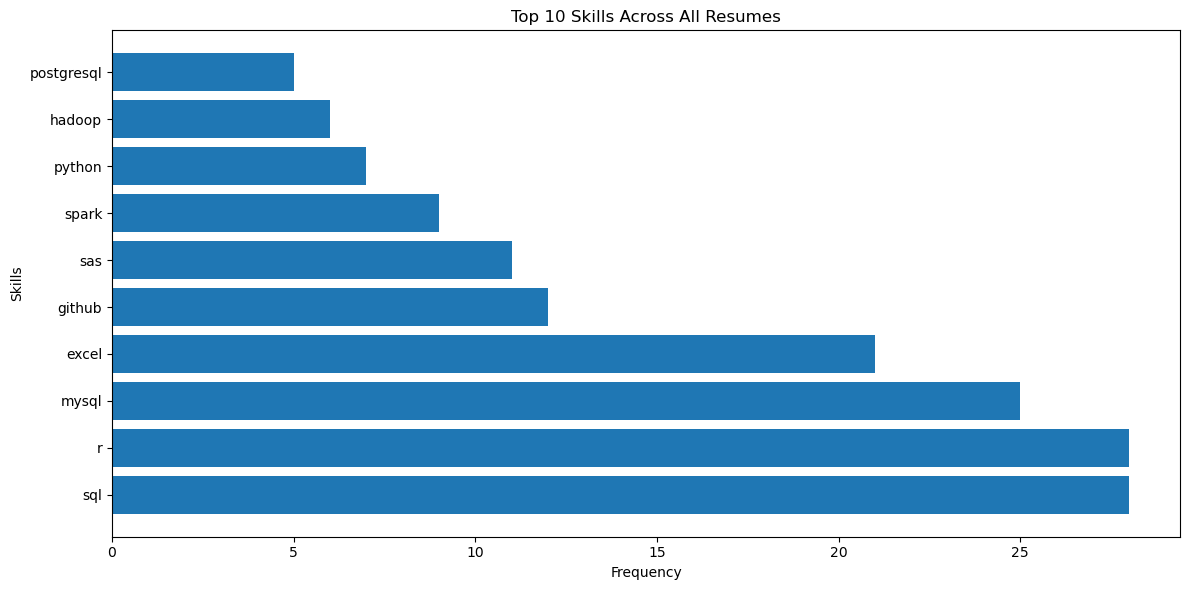

In [10]:
top_skills = skill_frequency.most_common(10)

skill_names = [x[0] for x in top_skills]
skill_counts = [x[1] for x in top_skills]

plt.figure(figsize=(12,6))

plt.barh(
    skill_names,
    skill_counts
)

plt.title("Top 10 Skills Across All Resumes")

plt.xlabel("Frequency")

plt.ylabel("Skills")

plt.tight_layout()

plt.show()

In [11]:
resume_df[
    [
        "resume_name",
        "skills_found",
        "skill_count"
    ]
].head()

,resume_name,skills_found,skill_count
0,Abiral_Pandey_Fullstack_Java.pdf,"[sql, excel, r, sas, mysql, postgresql, github]",7
1,Anudeep N_Sr Java Developer.pdf,"[sql, r, sas, mysql, github]",5
2,Ashwini J2EE Developer.pdf,"[sql, excel, r, mysql, postgresql, github, spark]",7
3,Bapuji Hadoop developer.pdf,"[python, sql, excel, tableau, r, mysql, github...",9
4,CHETAN_Sr Java Developer.pdf,"[sql, excel, r, mysql]",4


In [12]:
resume_df.to_csv(
    r"D:\AI_ATS_Resume_Screening_System\resume\test\csv\skills_data.csv",
    index=False
)

print("Skills dataset saved successfully!")

Skills dataset saved successfully!
